# Combine models

A variable belongs to one model at a time. Copy a model or its components when
you want an independent version; share variables deliberately when combining
two response models.

## Copy a submodel

For `model` from {doc}`tutorials/notebooks/11-model-building`:

In [1]:
import jax
import jax.numpy as jnp
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl

In [2]:
# Python cell fragment: imports are visible in each guide.
x_data = jnp.linspace(-1.0, 1.0, 80)
y_data = 1.0 + 2.0 * x_data + 0.7 * jax.random.normal(jax.random.key(42), (80,))

prior_scale = lsl.Var.new_value(2.5, name="prior_scale")
beta = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=prior_scale),
    name="beta",
)
variance = lsl.Var.new_param(
    1.0,
    dist=lsl.Dist(tfd.LogNormal, loc=0.0, scale=0.5),
    name="variance",
)
x = lsl.Var.new_obs(x_data, name="x")

mu = lsl.Var.new_calc(
    lambda x, b: b[0] + b[1] * x,
    x,
    beta,
    name="mu",
)
sigma = lsl.Var.new_calc(jnp.sqrt, variance, name="sigma")
y = lsl.Var.new_obs(
    y_data,
    dist=lsl.Dist(tfd.Normal, loc=mu, scale=sigma),
    name="y",
)
model = lsl.Model(y)

# Match the tutorial after its reactive update.
beta.value = jnp.array([1.0, 2.0])


In [3]:
mean_model = model.parental_submodel("mu")

In [4]:
sorted(mean_model.vars)

['beta', 'mu', 'prior_scale', 'x']

The parental submodel contains copies of `mu` and its ancestors: covariate
`x`, coefficients `beta`, and their prior scale. It excludes `y` and the
response variance. Changing the copy does not change the original variables.

## Add a response

This complete example creates two groups of observations:

In [5]:
mean_a = lsl.Var.new_param(
    0.0,
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=2.0),
    name="mean",
)
y_a = lsl.Var.new_obs(
    jnp.array([0.8, 1.2]),
    dist=lsl.Dist(tfd.Normal, loc=mean_a, scale=1.0),
    name="y_a",
)
group_a = lsl.Model(y_a)

mean_b = lsl.Var.new_param(
    0.0,
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=2.0),
    name="mean",
)
y_b = lsl.Var.new_obs(
    jnp.array([1.4, 1.6]),
    dist=lsl.Dist(tfd.Normal, loc=mean_b, scale=0.5),
    name="y_b",
)
group_b = lsl.Model(y_b)

separate = group_a.copy()
other = group_b.copy()
other.prefix_names("b_")
separate.add(other, copy=True);

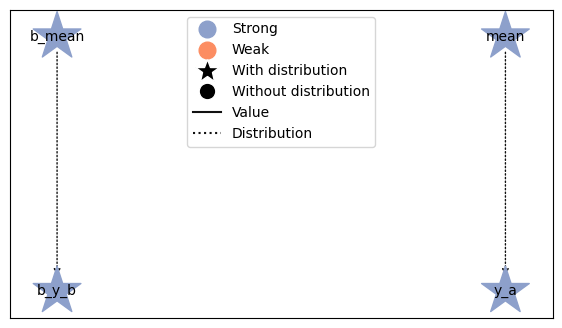

In [6]:
separate.plot(width=7, height=4)

In [7]:
sorted(separate.parameters)

['b_mean', 'mean']

This model has two means, `mean` and `b_mean`. Prefixing the second group's
names avoids collisions: `add` requires unique names. `copy=True` preserves
the source model; the default `copy=False` moves its contents and empties it.

## Share a parameter

In [8]:
shared = group_a.copy()
shared.join(group_b, by=["mean"], copy=True);

liesel.model.model - INFO - Joining by: mean


In [9]:
sorted(shared.parameters)

['mean']

In [10]:
shared.vars["y_b"].dist_node["loc"] is shared.vars["mean"]

True

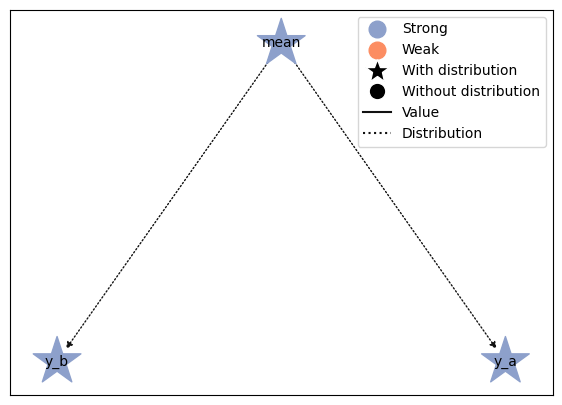

In [11]:
shared.plot(width=7, height=5)

There is one `mean` parameter, and the identity check returns `True`. Both
responses depend on the receiving model's mean and its prior. The second
model's same-named mean is replaced, including its prior; joining does not
multiply two priors for the shared parameter.

Names listed in `by` are shared. Other overlapping names receive suffixes
(`.x` and `.y` by default). `copy=True` keeps `group_b` usable;
without it, joining consumes that model. See {meth}`~liesel.model.Model.join`
for the exact collision rules.